# DBSCAN Ambiguity Rate Analysis

Analyze ambiguity rates and cluster counts across parameter choices to identify the optimal clustering scale.

**Key insight**: Ambiguity rate detects over-merging. When two real structures merge, multiple halos from the same realization end up in one DBSCAN cluster, increasing ambiguity.

In [33]:
import numpy as np
import h5py
import re
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pymanticore.analysis.matplotlib import get_mplstyle_path

OUTPUT_DIR = Path("../output")

# File pattern for DBSCAN posterior clusters
FILE_PATTERN = "dbscan_clusters_eps_*_ms_*.h5"

# Minimum clusters to consider a run valid (exclude phase-transition regimes)
MIN_CLUSTERS = 100

print(f"Looking for: {FILE_PATTERN}")

# Set plotting style
mnras_style = "mnras"

Looking for: dbscan_clusters_eps_*_ms_*.h5


In [22]:
def parse_filename(filename):
    """Extract (eps, min_samples) from filename."""
    match = re.search(r'eps_([\d.]+)_ms_(\d+)', filename)
    if match:
        return float(match.group(1)), int(match.group(2))
    return None, None

def load_cluster_summary(filepath):
    """Load cluster summary statistics from HDF5 file."""
    with h5py.File(filepath, 'r') as f:
        summary = f['summary']
        
        data = {
            'n_clusters': len(summary['cluster_id'][:]),
            'ambiguity_rates': summary['ambiguity_rate'][:],
            'n_members': summary['n_members'][:],
            'existence_prob': summary['existence_prob'][:],
            'mean_m200_mass': summary['mean_m200_mass'][:],
        }
        
        # Compute summary stats
        valid_ambiguity = data['ambiguity_rates'][~np.isnan(data['ambiguity_rates'])]
        data['mean_ambiguity'] = np.mean(valid_ambiguity) if len(valid_ambiguity) > 0 else np.nan
        data['median_ambiguity'] = np.median(valid_ambiguity) if len(valid_ambiguity) > 0 else np.nan
        data['frac_zero_ambiguity'] = np.sum(valid_ambiguity == 0) / len(valid_ambiguity) if len(valid_ambiguity) > 0 else np.nan
        data['frac_low_ambiguity'] = np.sum(valid_ambiguity < 0.1) / len(valid_ambiguity) if len(valid_ambiguity) > 0 else np.nan
        
    return data

# Find and load all parameter runs
files = sorted(OUTPUT_DIR.glob(FILE_PATTERN))
print(f"Found {len(files)} parameter runs")

all_runs = {}
for f in tqdm(files, desc="Loading"):
    eps, ms = parse_filename(f.name)
    if eps is not None:
        all_runs[(eps, ms)] = load_cluster_summary(f)

# Filter degenerate runs
runs = {k: v for k, v in all_runs.items() if v['n_clusters'] >= MIN_CLUSTERS}
excluded = {k: v for k, v in all_runs.items() if v['n_clusters'] < MIN_CLUSTERS}

print(f"\nValid runs: {len(runs)}")
print(f"Excluded (< {MIN_CLUSTERS} clusters): {len(excluded)}")
if excluded:
    print(f"  Excluded: {[(k, v['n_clusters']) for k, v in sorted(excluded.items())]}")

Found 666 parameter runs


Loading: 100%|██████████| 666/666 [00:03<00:00, 209.61it/s]


Valid runs: 657
Excluded (< 100 clusters): 9
  Excluded: [((1.0, 14), 83), ((1.0, 15), 74), ((1.0, 16), 65), ((1.0, 17), 53), ((1.0, 18), 50), ((1.0, 19), 45), ((1.0, 20), 44), ((1.25, 19), 94), ((1.25, 20), 85)]


In [23]:
# Summary table
print(f"{'eps':>8} {'ms':>6} {'n_clust':>10} {'mean_amb':>10} {'med_amb':>10} {'frac<0.1':>10}")
print("-" * 60)

for params in sorted(runs.keys()):
    r = runs[params]
    print(f"{params[0]:>8.2f} {params[1]:>6} {r['n_clusters']:>10} "
          f"{r['mean_ambiguity']:>10.3f} {r['median_ambiguity']:>10.3f} "
          f"{r['frac_low_ambiguity']:>10.1%}")

     eps     ms    n_clust   mean_amb    med_amb   frac<0.1
------------------------------------------------------------
    1.00      3       3224      0.000      0.000      99.9%
    1.00      4       1454      0.001      0.000     100.0%
    1.00      5        829      0.000      0.000     100.0%
    1.00      6        543      0.001      0.000     100.0%
    1.00      7        393      0.000      0.000     100.0%
    1.00      8        307      0.000      0.000     100.0%
    1.00      9        235      0.001      0.000     100.0%
    1.00     10        183      0.000      0.000     100.0%
    1.00     11        149      0.000      0.000     100.0%
    1.00     12        124      0.000      0.000     100.0%
    1.00     13        101      0.000      0.000     100.0%
    1.25      3       4231      0.002      0.000      99.8%
    1.25      4       1992      0.002      0.000      99.7%
    1.25      5       1186      0.003      0.000      99.6%
    1.25      6        818      0.002  

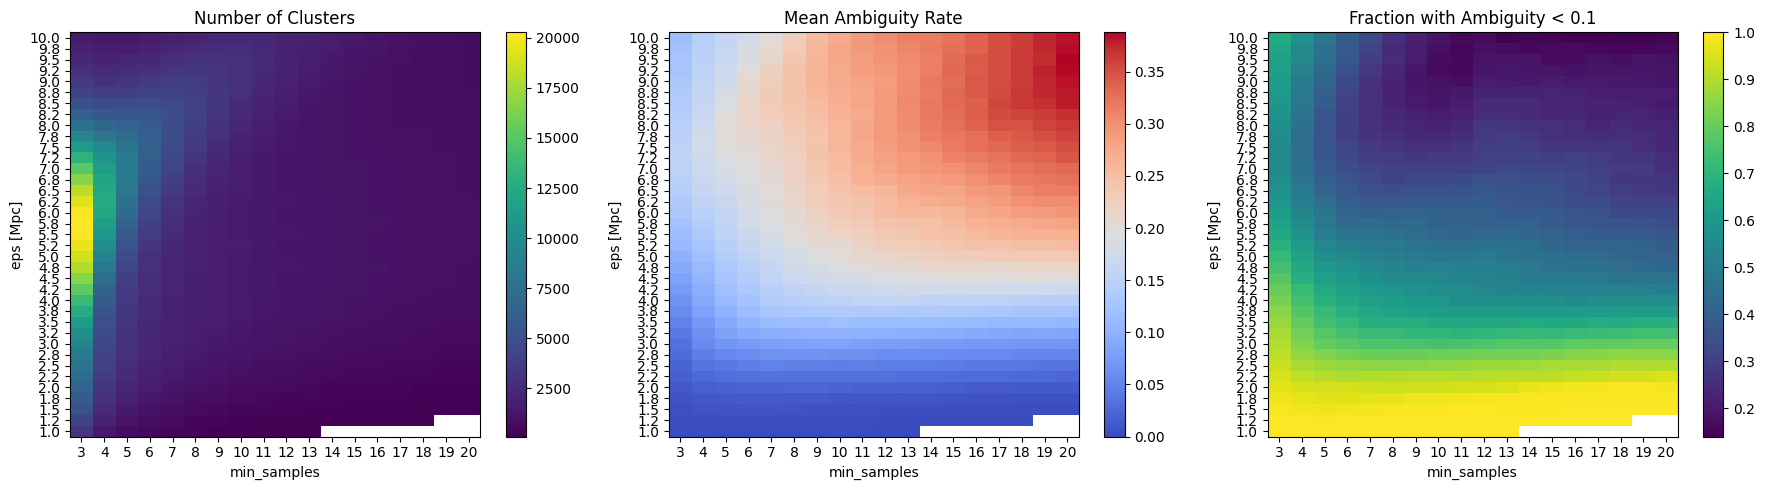

In [24]:
# Build 2D grids for heatmaps
eps_values = sorted(set(p[0] for p in runs.keys()))
ms_values = sorted(set(p[1] for p in runs.keys()))

n_clusters_grid = np.full((len(eps_values), len(ms_values)), np.nan)
mean_ambiguity_grid = np.full((len(eps_values), len(ms_values)), np.nan)
frac_low_ambiguity_grid = np.full((len(eps_values), len(ms_values)), np.nan)

for (eps, ms), data in runs.items():
    i = eps_values.index(eps)
    j = ms_values.index(ms)
    n_clusters_grid[i, j] = data['n_clusters']
    mean_ambiguity_grid[i, j] = data['mean_ambiguity']
    frac_low_ambiguity_grid[i, j] = data['frac_low_ambiguity']

# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eps_labels = [f"{v:.1f}" for v in eps_values]
ms_labels = [str(v) for v in ms_values]

# Number of clusters
ax = axes[0]
im = ax.imshow(n_clusters_grid, cmap='viridis', aspect='auto', origin='lower')
ax.set_xticks(range(len(ms_values)))
ax.set_xticklabels(ms_labels)
ax.set_yticks(range(len(eps_values)))
ax.set_yticklabels(eps_labels)
ax.set_xlabel('min_samples')
ax.set_ylabel('eps [Mpc]')
ax.set_title('Number of Clusters')
plt.colorbar(im, ax=ax)

# Mean ambiguity rate
ax = axes[1]
im = ax.imshow(mean_ambiguity_grid, cmap='coolwarm', aspect='auto', origin='lower')
ax.set_xticks(range(len(ms_values)))
ax.set_xticklabels(ms_labels)
ax.set_yticks(range(len(eps_values)))
ax.set_yticklabels(eps_labels)
ax.set_xlabel('min_samples')
ax.set_ylabel('eps [Mpc]')
ax.set_title('Mean Ambiguity Rate')
plt.colorbar(im, ax=ax)

# Fraction with low ambiguity
ax = axes[2]
im = ax.imshow(frac_low_ambiguity_grid, cmap='viridis', aspect='auto', origin='lower')
ax.set_xticks(range(len(ms_values)))
ax.set_xticklabels(ms_labels)
ax.set_yticks(range(len(eps_values)))
ax.set_yticklabels(eps_labels)
ax.set_xlabel('min_samples')
ax.set_ylabel('eps [Mpc]')
ax.set_title('Fraction with Ambiguity < 0.1')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

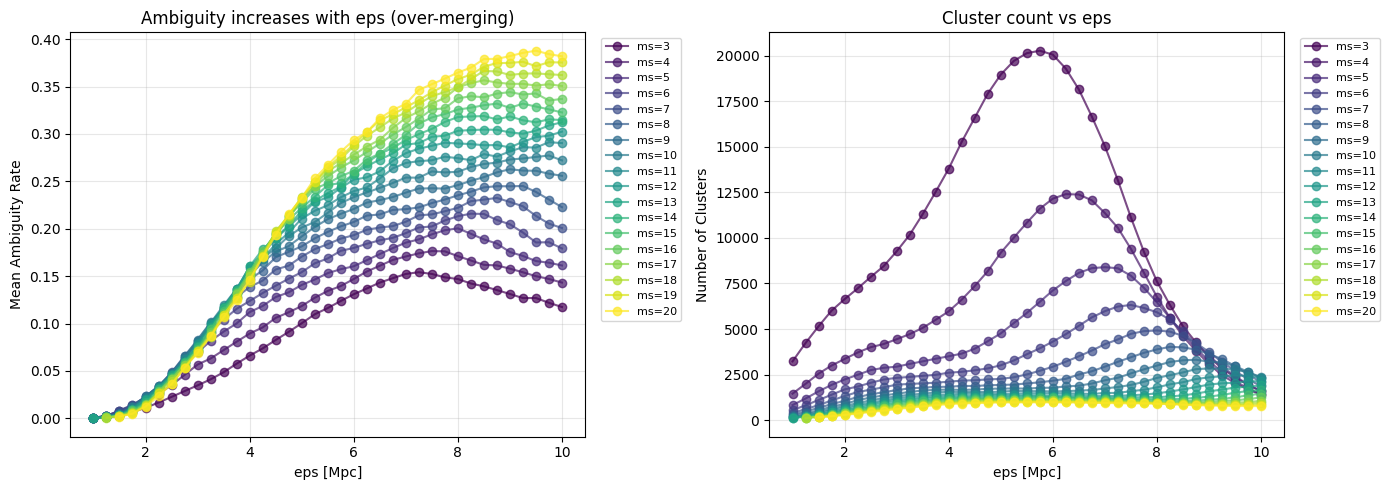

In [25]:
# Plot ambiguity vs eps for different min_samples values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Group by min_samples
ms_groups = defaultdict(list)
for (eps, ms), data in sorted(runs.items()):
    ms_groups[ms].append((eps, data))

colors = plt.cm.viridis(np.linspace(0, 1, len(ms_groups)))

# Left: Mean ambiguity vs eps
ax = axes[0]
for (ms, group), color in zip(sorted(ms_groups.items()), colors):
    eps_vals = [g[0] for g in group]
    amb_vals = [g[1]['mean_ambiguity'] for g in group]
    ax.plot(eps_vals, amb_vals, 'o-', label=f'ms={ms}', color=color, alpha=0.7)

ax.set_xlabel('eps [Mpc]')
ax.set_ylabel('Mean Ambiguity Rate')
ax.set_title('Ambiguity increases with eps (over-merging)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Number of clusters vs eps
ax = axes[1]
for (ms, group), color in zip(sorted(ms_groups.items()), colors):
    eps_vals = [g[0] for g in group]
    n_vals = [g[1]['n_clusters'] for g in group]
    ax.plot(eps_vals, n_vals, 'o-', label=f'ms={ms}', color=color, alpha=0.7)

ax.set_xlabel('eps [Mpc]')
ax.set_ylabel('Number of Clusters')
ax.set_title('Cluster count vs eps')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

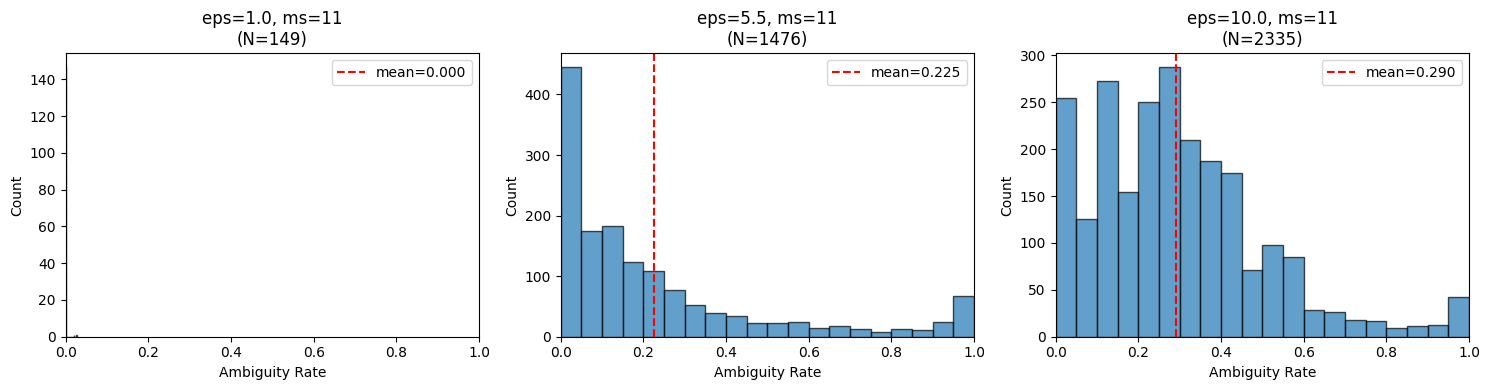


As eps increases, ambiguity rate increases (more over-merging).
The 'sweet spot' is where we have many clusters but low ambiguity.


In [26]:
# Compare ambiguity distributions for a few representative eps values
# Pick low, medium, high eps at a fixed min_samples
target_ms = 11  # or pick another

eps_at_ms = sorted([eps for (eps, ms) in runs.keys() if ms == target_ms])
if len(eps_at_ms) >= 3:
    selected_eps = [eps_at_ms[0], eps_at_ms[len(eps_at_ms)//2], eps_at_ms[-1]]
else:
    selected_eps = eps_at_ms

fig, axes = plt.subplots(1, len(selected_eps), figsize=(5*len(selected_eps), 4))
if len(selected_eps) == 1:
    axes = [axes]

for ax, eps in zip(axes, selected_eps):
    data = runs[(eps, target_ms)]
    amb = data['ambiguity_rates']
    amb = amb[~np.isnan(amb)]
    
    ax.hist(amb, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(amb), color='red', linestyle='--', label=f'mean={np.mean(amb):.3f}')
    ax.set_xlabel('Ambiguity Rate')
    ax.set_ylabel('Count')
    ax.set_title(f'eps={eps:.1f}, ms={target_ms}\n(N={data["n_clusters"]})')
    ax.legend()
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nAs eps increases, ambiguity rate increases (more over-merging).")
print(f"The 'sweet spot' is where we have many clusters but low ambiguity.")

In [27]:
# Find optimal parameters: maximize clusters while keeping ambiguity low
# Score = n_clusters * (1 - mean_ambiguity)  or similar

scores = {}
for params, data in runs.items():
    # Penalize high ambiguity
    scores[params] = {
        'n_clusters': data['n_clusters'],
        'mean_ambiguity': data['mean_ambiguity'],
        'n_low_ambiguity': int(data['frac_low_ambiguity'] * data['n_clusters']),
        # Score: number of clusters with low ambiguity
        'score': data['frac_low_ambiguity'] * data['n_clusters']
    }

# Best by different criteria
best_by_count = max(scores.keys(), key=lambda p: scores[p]['n_clusters'])
best_by_low_amb = max(scores.keys(), key=lambda p: scores[p]['n_low_ambiguity'])
best_by_score = max(scores.keys(), key=lambda p: scores[p]['score'])

print("Optimal parameter selection:")
print(f"\n  Best by total clusters: eps={best_by_count[0]:.1f}, ms={best_by_count[1]}")
print(f"    -> {scores[best_by_count]['n_clusters']} clusters, "
      f"mean_amb={scores[best_by_count]['mean_ambiguity']:.3f}")

print(f"\n  Best by low-ambiguity count: eps={best_by_low_amb[0]:.1f}, ms={best_by_low_amb[1]}")
print(f"    -> {scores[best_by_low_amb]['n_low_ambiguity']} clusters with amb<0.1, "
      f"mean_amb={scores[best_by_low_amb]['mean_ambiguity']:.3f}")

print(f"\n  Best by score (n * frac_low_amb): eps={best_by_score[0]:.1f}, ms={best_by_score[1]}")
print(f"    -> score={scores[best_by_score]['score']:.1f}, "
      f"mean_amb={scores[best_by_score]['mean_ambiguity']:.3f}")

Optimal parameter selection:

  Best by total clusters: eps=5.8, ms=3
    -> 20268 clusters, mean_amb=0.124

  Best by low-ambiguity count: eps=5.0, ms=3
    -> 13602 clusters with amb<0.1, mean_amb=0.100

  Best by score (n * frac_low_amb): eps=5.0, ms=3
    -> score=13602.0, mean_amb=0.100


Fiducial parameters: eps=4.0, min_samples=11
  Total clusters: 1405
  Mean ambiguity: 0.159
  Median ambiguity: 0.071
  Fraction with ambiguity=0: 33.7%
  Fraction with ambiguity<0.1: 56.7%


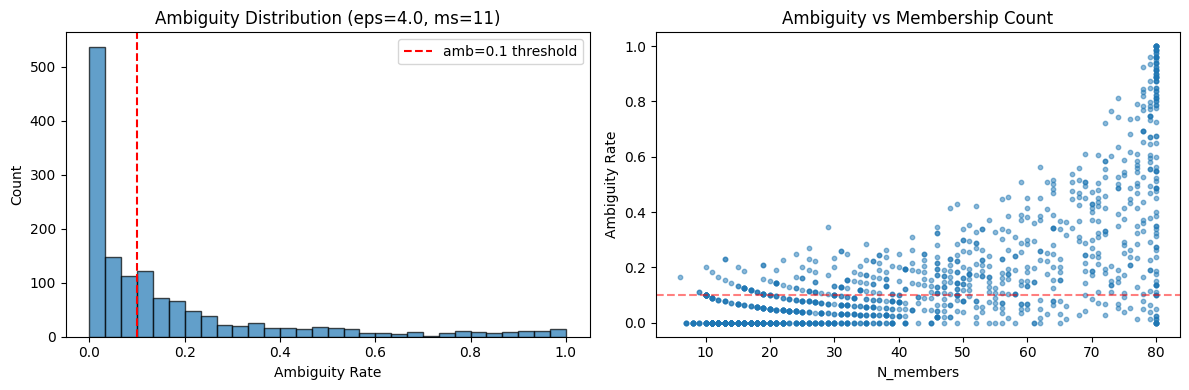

In [28]:
# Detailed look at fiducial parameters
FIDUCIAL = (4.0, 11)  # Set your fiducial here

if FIDUCIAL in runs:
    data = runs[FIDUCIAL]
    
    print(f"Fiducial parameters: eps={FIDUCIAL[0]}, min_samples={FIDUCIAL[1]}")
    print(f"  Total clusters: {data['n_clusters']}")
    print(f"  Mean ambiguity: {data['mean_ambiguity']:.3f}")
    print(f"  Median ambiguity: {data['median_ambiguity']:.3f}")
    print(f"  Fraction with ambiguity=0: {data['frac_zero_ambiguity']:.1%}")
    print(f"  Fraction with ambiguity<0.1: {data['frac_low_ambiguity']:.1%}")
    
    # Ambiguity distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    amb = data['ambiguity_rates'][~np.isnan(data['ambiguity_rates'])]
    
    ax = axes[0]
    ax.hist(amb, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0.1, color='red', linestyle='--', label='amb=0.1 threshold')
    ax.set_xlabel('Ambiguity Rate')
    ax.set_ylabel('Count')
    ax.set_title(f'Ambiguity Distribution (eps={FIDUCIAL[0]}, ms={FIDUCIAL[1]})')
    ax.legend()
    
    # Ambiguity vs n_members
    ax = axes[1]
    ax.scatter(data['n_members'], data['ambiguity_rates'], alpha=0.5, s=10)
    ax.set_xlabel('N_members')
    ax.set_ylabel('Ambiguity Rate')
    ax.set_title('Ambiguity vs Membership Count')
    ax.axhline(0.1, color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Fiducial {FIDUCIAL} not found in runs. Available: {sorted(runs.keys())}")

Analyzing min_samples values at eps=3.0: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


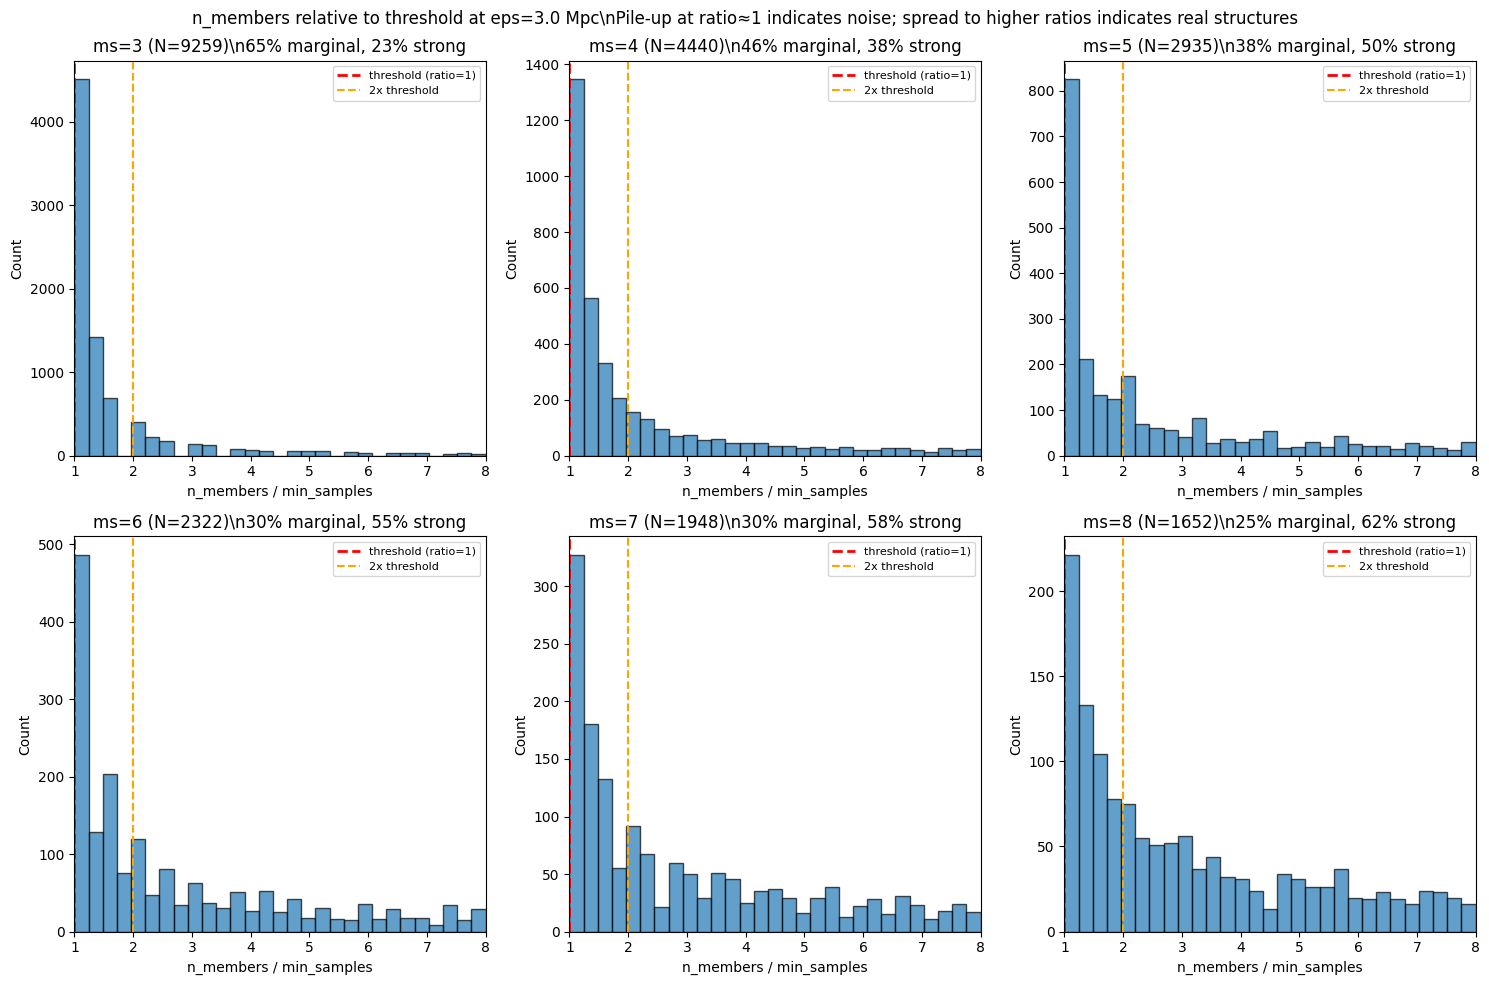

In [29]:
# Diagnostic: n_members distribution relative to min_samples threshold
# Real structures should have n_members >> min_samples
# Noise should pile up at n_members ≈ min_samples

# Fix eps at a value where ambiguity is low (e.g., eps where ambiguity crosses 5%)
TARGET_EPS = 3.0  # Adjust based on your ambiguity threshold

# Get all min_samples values at this eps
ms_at_eps = sorted([ms for (eps, ms) in runs.keys() if eps == TARGET_EPS])
print(f"Analyzing min_samples values at eps={TARGET_EPS}: {ms_at_eps}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, ms in zip(axes, ms_at_eps[:6]):  # Show up to 6
    if (TARGET_EPS, ms) not in runs:
        continue
    
    data = runs[(TARGET_EPS, ms)]
    n_mem = data['n_members']
    
    # Ratio of n_members to min_samples
    ratio = n_mem / ms
    
    # Histogram
    bins = np.linspace(1, 8, 30)  # ratio from 1x to 8x threshold
    ax.hist(ratio, bins=bins, edgecolor='black', alpha=0.7)
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='threshold (ratio=1)')
    ax.axvline(2.0, color='orange', linestyle='--', linewidth=1.5, label='2x threshold')
    
    # Stats
    frac_marginal = np.sum(ratio < 1.5) / len(ratio)
    frac_strong = np.sum(ratio > 2) / len(ratio)
    
    ax.set_xlabel('n_members / min_samples')
    ax.set_ylabel('Count')
    ax.set_title(f'ms={ms} (N={len(n_mem)})\\n{frac_marginal:.0%} marginal, {frac_strong:.0%} strong')
    ax.legend(fontsize=8)
    ax.set_xlim(1, 8)

plt.suptitle(f'n_members relative to threshold at eps={TARGET_EPS} Mpc\\n'
             'Pile-up at ratio≈1 indicates noise; spread to higher ratios indicates real structures', 
             fontsize=12)
plt.tight_layout()
plt.show()

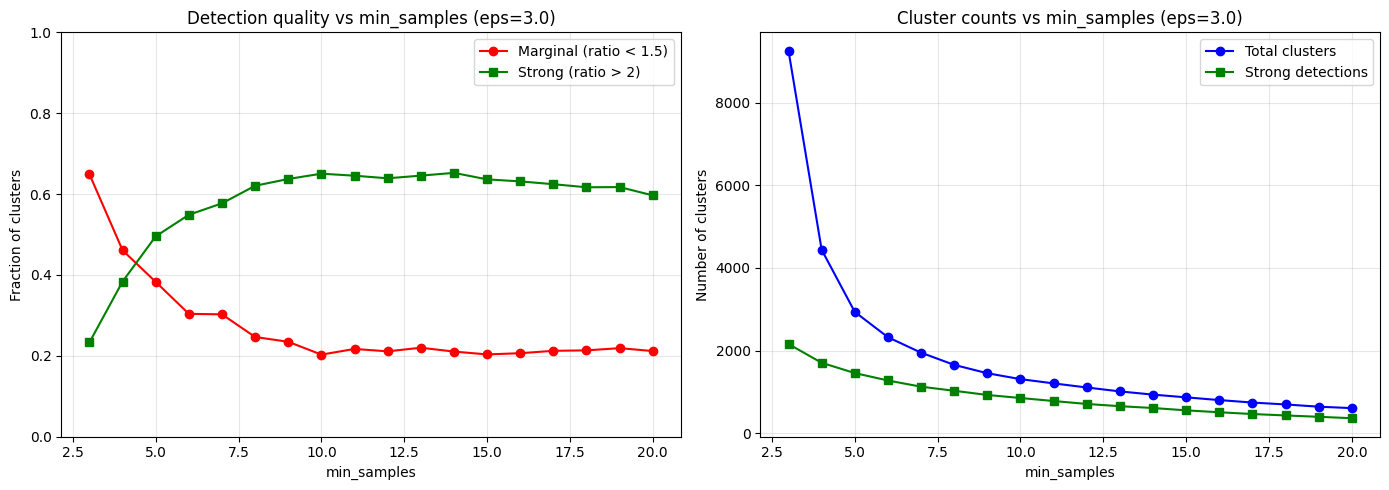

\nSummary at eps=3.0 Mpc:
    ms    N_clust   N_strong  %marginal    %strong  med_ratio
------------------------------------------------------------
     3       9259       2157      64.9%      23.3%       1.33
     4       4440       1703      46.1%      38.4%       1.50
     5       2935       1454      38.3%      49.5%       2.00
     6       2322       1274      30.4%      54.9%       2.50
     7       1948       1124      30.2%      57.7%       2.71
     8       1652       1025      24.6%      62.0%       3.00
     9       1450        924      23.4%      63.7%       3.00
    10       1307        850      20.3%      65.0%       3.00
    11       1204        777      21.7%      64.5%       2.91
    12       1105        706      21.1%      63.9%       2.83
    13       1010        652      22.0%      64.6%       2.77
    14        932        608      21.0%      65.2%       2.71
    15        866        551      20.3%      63.6%       2.60
    16        800        505      20.6%      

In [30]:
# Summary: fraction of "strong" detections (n_members > 2*min_samples) vs min_samples
# This helps identify where noise starts dominating

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect stats for all min_samples at fixed eps
stats_by_ms = []
for ms in ms_at_eps:
    if (TARGET_EPS, ms) not in runs:
        continue
    data = runs[(TARGET_EPS, ms)]
    n_mem = data['n_members']
    ratio = n_mem / ms
    
    stats_by_ms.append({
        'ms': ms,
        'n_clusters': len(n_mem),
        'frac_marginal': np.sum(ratio < 1.5) / len(ratio),  # barely above threshold
        'frac_strong': np.sum(ratio > 2) / len(ratio),       # well above threshold
        'median_ratio': np.median(ratio),
        'n_strong': np.sum(ratio > 2),  # absolute count of strong detections
    })

ms_vals = [s['ms'] for s in stats_by_ms]

# Left: fractions
ax = axes[0]
ax.plot(ms_vals, [s['frac_marginal'] for s in stats_by_ms], 'o-', label='Marginal (ratio < 1.5)', color='red')
ax.plot(ms_vals, [s['frac_strong'] for s in stats_by_ms], 's-', label='Strong (ratio > 2)', color='green')
ax.set_xlabel('min_samples')
ax.set_ylabel('Fraction of clusters')
ax.set_title(f'Detection quality vs min_samples (eps={TARGET_EPS})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# Right: absolute counts
ax = axes[1]
ax.plot(ms_vals, [s['n_clusters'] for s in stats_by_ms], 'o-', label='Total clusters', color='blue')
ax.plot(ms_vals, [s['n_strong'] for s in stats_by_ms], 's-', label='Strong detections', color='green')
ax.set_xlabel('min_samples')
ax.set_ylabel('Number of clusters')
ax.set_title(f'Cluster counts vs min_samples (eps={TARGET_EPS})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print(f"\\nSummary at eps={TARGET_EPS} Mpc:")
print(f"{'ms':>6} {'N_clust':>10} {'N_strong':>10} {'%marginal':>10} {'%strong':>10} {'med_ratio':>10}")
print("-" * 60)
for s in stats_by_ms:
    print(f"{s['ms']:>6} {s['n_clusters']:>10} {s['n_strong']:>10} "
          f"{s['frac_marginal']:>10.1%} {s['frac_strong']:>10.1%} {s['median_ratio']:>10.2f}")

print(f"\\nInterpretation:")
print(f"  - High %marginal = many clusters barely above threshold (likely noise)")
print(f"  - High %strong = clusters have n_members well above min_samples (real structures)")
print(f"  - Look for min_samples where %strong is high but N_strong hasn't dropped too much")

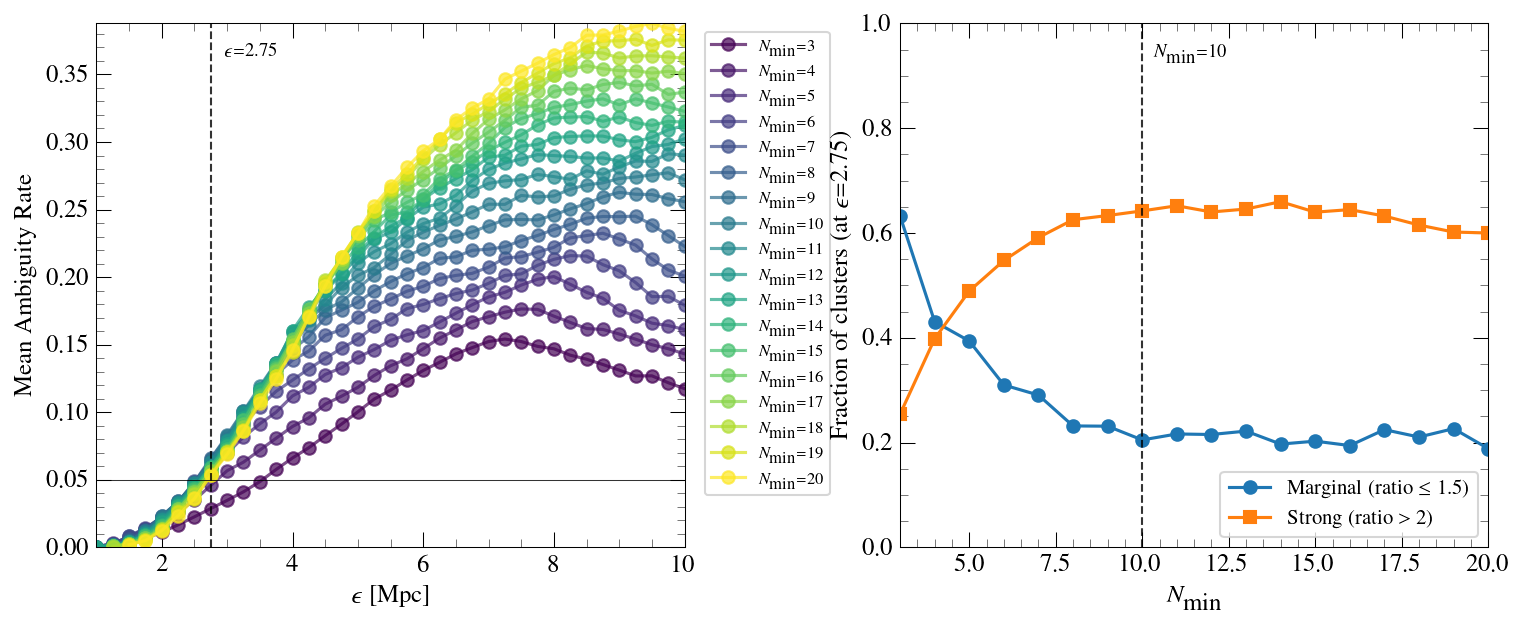

In [52]:
CHOSEN_EPS = 2.75  # selected eps value (Mpc)

# ---- Left panel prep: group runs by min_samples ----
ms_groups = defaultdict(list)
for (eps, ms), data in sorted(runs.items()):
    ms_groups[ms].append((eps, data))

colors = plt.cm.viridis(np.linspace(0, 1, len(ms_groups)))

# ---- Right panel prep: stats vs min_samples at CHOSEN_EPS ----
stats_by_ms = []
for ms in ms_at_eps:
    key = (CHOSEN_EPS, ms)
    if key not in runs:
        continue
    data = runs[key]
    n_mem = np.asarray(data["n_members"])
    if n_mem.size == 0:
        continue

    ratio = n_mem / ms
    stats_by_ms.append({
        "ms": ms,
        "n_clusters": n_mem.size,
        "frac_marginal": np.mean(ratio < 1.5),   # barely above threshold
        "frac_strong":   np.mean(ratio > 2.0),   # well above threshold
        "median_ratio":  np.median(ratio),
        "n_strong":      int(np.sum(ratio > 2.0)),
    })

# sort for plotting
stats_by_ms = sorted(stats_by_ms, key=lambda d: d["ms"])
ms_vals = [s["ms"] for s in stats_by_ms]

# ---- Plot ----
with plt.style.context(get_mplstyle_path(mnras_style)):
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Left: Mean ambiguity vs eps (for each min_samples) + vertical line at chosen eps
    ax = axes[0]
    for (ms, group), color in zip(sorted(ms_groups.items()), colors):
        eps_vals = [g[0] for g in group]
        amb_vals = [g[1]["mean_ambiguity"] for g in group]
        ax.plot(eps_vals, amb_vals, "o-", label=r"$N_{\textrm{min}}$" + f"={ms}", color=color, alpha=0.7)
    
    ax.axvline(CHOSEN_EPS, color="k", linestyle="--", linewidth=1, alpha=0.8)
    ax.axhline(0.05, color="k", lw=0.5, alpha=0.8)
    ax.text(CHOSEN_EPS + 0.2, 0.96, rf"$\epsilon$={CHOSEN_EPS:.2f}",
            transform=ax.get_xaxis_transform(),
            ha="left", va="top", fontsize=9)
    
    ax.set_xlabel(r"$\epsilon$ [Mpc]")
    ax.set_ylabel("Mean Ambiguity Rate")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    
    # Right: Fractions vs min_samples at chosen eps (from your 2nd figure left panel)
    ax = axes[1]
    if len(stats_by_ms) == 0:
        ax.text(0.5, 0.5, f"No runs found at eps={CHOSEN_EPS}",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
    else:
        ax.plot(ms_vals, [s["frac_marginal"] for s in stats_by_ms], "o-",
                label=r"Marginal (ratio $\leq$ 1.5)")
        ax.plot(ms_vals, [s["frac_strong"] for s in stats_by_ms], "s-",
                label=r"Strong (ratio $>$ 2)")
        ax.set_xlabel(r"$N_{\textrm{min}}$")
        ax.set_ylabel(r"Fraction of clusters (at $\epsilon$=2.75)")
        ax.set_ylim(0, 1)
        ax.legend()
        ax.axvline(10, color="k", linestyle="--", linewidth=1, alpha=0.8)
        ax.text(10 + 0.3, 0.96, r"$N_{\textrm{min}}$" + f"=10",
                transform=ax.get_xaxis_transform(),
                ha="left", va="top", fontsize=9)
    
    plt.tight_layout(pad=0.1)
    plt.savefig("plots/dbscan_fiducial_params.pdf")
    plt.show()
